# 사용자 자유응답(Q18) 텍스트 분석

---

## 분석 개요

`07_text_analysis`의 **SQL은 데이터 추출 + 그룹 라벨링뿐**이다 — 한 개의 SQL 파일 `../sql/07_text_analysis.sql`에 `-- name:` 마커로 모았다. 형태소 분석(Okt)·키워드 빈도·카테고리 분류·워드클라우드·NPS×카테고리 교차는 DB에 없는 파생 결과(`nouns`/`categories`)를 만들어 집계하므로 **전부 노트북 pandas/NLP**다.

| 분석 단계 | 처리 위치 | 이유 |
|-----------|-----------|------|
| Q18 응답 추출, Non-User/NPS 그룹 라벨, Non-User 인구통계 | **SQL** (`-- name:` 쿼리) | 추출·라벨링은 SQL |
| 형태소(Okt)·키워드 빈도·워드클라우드 | **pandas/KoNLPy** | 한국어 NLP는 SQL 부적합 |
| 키워드 카테고리 분류·카테고리 집계·NPS×카테고리 교차 | **pandas** | 카테고리는 DB에 없는 파생 컬럼 |

- 분석 대상: Q18 자유응답 유효 92건 (Non-User 24 · Detractor 31 · Passive 30 · Promoter 7)
- SQL 단계에서 `feedback IS NOT NULL` 응답 중 비해당 응답 1건을 제외해, 최종 유효 자유응답 92건을 분석 대상으로 한다.
- ⚠️ **데이터 한계**: 자유응답 표본이 작고(특히 Promoter n=7) 자기보고라, 키워드·카테고리 비율은 방향성 참고용이다.
- ⚠️ Okt(KoNLPy) 실행에는 `.env`의 `JAVA_HOME`과 konlpy·wordcloud 설치가 필요하다.

In [1]:
# Java 환경변수 (Okt 작동에 필수)
# .env의 JAVA_HOME만 사용 — 하드코딩된 OS 의존 경로 없음
# 다른 환경에서 시작 시 .env.example을 .env로 복사 후 자기 JDK 경로 입력
# ※ load_dotenv()는 konlpy import 전에 호출되어야 JPype1이 JAVA_HOME 인식
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

if 'JAVA_HOME' not in os.environ:
    raise RuntimeError(
        'JAVA_HOME 환경변수가 설정되지 않았습니다.\n'
        '.env 파일에 JAVA_HOME=<JDK 설치 경로> 를 추가해주세요.\n'
        '(환경별 경로 예시는 .env.example 참조)'
    )

import re
import pandas as pd
import numpy as np
from collections import Counter
from scipy import stats
import plotly.graph_objects as go
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

from konlpy.tag import Okt
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# matplotlib 한글 폰트 (워드클라우드 title 등 한글 깨짐 방지)
# 시스템에서 사용 가능한 첫 폰트로 자동 설정 (macOS·Linux·Windows 호환)
_preferred_fonts = ['Apple SD Gothic Neo', 'AppleGothic', 'Nanum Gothic', 'Noto Sans CJK KR', 'Malgun Gothic']
_available = {f.name for f in fm.fontManager.ttflist}
for _font in _preferred_fonts:
    if _font in _available:
        plt.rcParams['font.family'] = _font
        break
plt.rcParams['axes.unicode_minus'] = False

In [2]:
DB_ENV_VARS = ['DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_NAME']
missing_db_vars = [name for name in DB_ENV_VARS if not os.getenv(name)]
if missing_db_vars:
    raise RuntimeError(f"DB 환경변수가 누락되었습니다: {', '.join(missing_db_vars)}")

db_url = URL.create(
    drivername='mysql+mysqlconnector',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    database=os.getenv('DB_NAME'),
)
engine = create_engine(db_url, pool_pre_ping=True)

In [3]:
import re

SQL_FILE = Path('../sql/07_text_analysis.sql')

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)
print('로드된 쿼리:', list(Q))

def run(name):
    return pd.read_sql(Q[name], engine)

로드된 쿼리: ['feedback_base', 'response_base', 'nonuser_demo']


In [4]:
# SQL 단계에서 feedback IS NOT NULL 중 비해당 응답 1건을 제외 → 유효 자유응답 92건
df = run('feedback_base')  # SQL은 ../sql/07_text_analysis.sql 의 -- name 블록

assert not df['user_group'].isna().any(), 'user_group 미분류 응답이 존재합니다.'
EXPECTED_ANALYSIS_COUNTS = {'Non-User': 24, 'Detractor': 31, 'Passive': 30, 'Promoter': 7}
assert df['user_group'].value_counts().to_dict() == EXPECTED_ANALYSIS_COUNTS
print(f'유효 자유응답: {len(df)}건 — {df["user_group"].value_counts().to_dict()}')

In [5]:
df.shape

(92, 12)

In [6]:
df.head()

,user_id,gender,age,uses_platform,platforms,purchase_count,continue_use,nps,feedback,user_group,nps_segment,category_eligible
0,1,남성,20대 후반,예,"무신사, 자라, 룩핀",3~5번,계속 사용할 것 같다,7.0,내가 생각했던 내 핏이 아니라서 반품과정이 번거롭다,Passive,Passive,True
1,2,남성,20대 후반,예,"무신사, KREAM",3~5번,아마 사용할 것 같다,7.0,재고가 없어서 배송이 느린 제품 가끔 존재함,Passive,Passive,True
2,4,남성,20대 후반,예,"무신사, 종합 쇼핑몰",1~2번,아마 사용할 것 같다,5.0,"무신사 같은 경우에, 수치 기입하는곳은 없고 키와 몸무게? + 연령대로 사이즈와 추...",Detractor,Detractor,True
3,6,남성,20대 후반,예,"무신사, KREAM",1~2번,아마 사용할 것 같다,6.0,"하나 찾아보면 그거만 보여줌 (ex : 와이드 데님 슬렉스 상품 구경 시, 홈 추천...",Detractor,Detractor,True
4,7,남성,20대 후반,아니오,None,None,None,NaN,복잡함,Non-User,None,True


---

## 1. Q18 응답 분포
- Q18. (선택) 패션 앱을 사용하면서 아쉬웠던 점이 있다면 자유롭게 적어주세요. (자유응답)

---

NPS 세그먼트별 Q18 응답률과 응답 길이를 살펴 어느 그룹이 적극적으로 응답하는지 관찰한다. 검정 없이 응답자 수·비율을 비교하는 기술통계 관찰이다.

In [7]:
# 4그룹별 응답률 (전체 모수 대비)
df_all = run('response_base')  # SQL은 ../sql/07_text_analysis.sql 의 -- name 블록
NON_COMPLAINT_RESPONSES = {'패션 앱을 자주 사용하지 않음'}  # 비해당 1건은 유효 응답에서 제외

df_all['has_valid_feedback'] = (
    df_all['feedback'].notna()
    & ~df_all['feedback'].fillna('').str.strip().isin(NON_COMPLAINT_RESPONSES)
).astype(int)

GROUP_ORDER = ['Non-User', 'Detractor', 'Passive', 'Promoter']

response_rate = (
    df_all
    .dropna(subset=['user_group'])
    .groupby('user_group')
    .agg(total=('has_valid_feedback', 'count'), responded=('has_valid_feedback', 'sum'))
    .reindex(GROUP_ORDER)
)
response_rate['응답률(%)'] = (response_rate['responded'] / response_rate['total'] * 100).round(1)
response_rate

,total,responded,응답률(%)
user_group,,,
Non-User,66,24,36.4
Detractor,88,31,35.2
Passive,88,30,34.1
Promoter,24,7,29.2


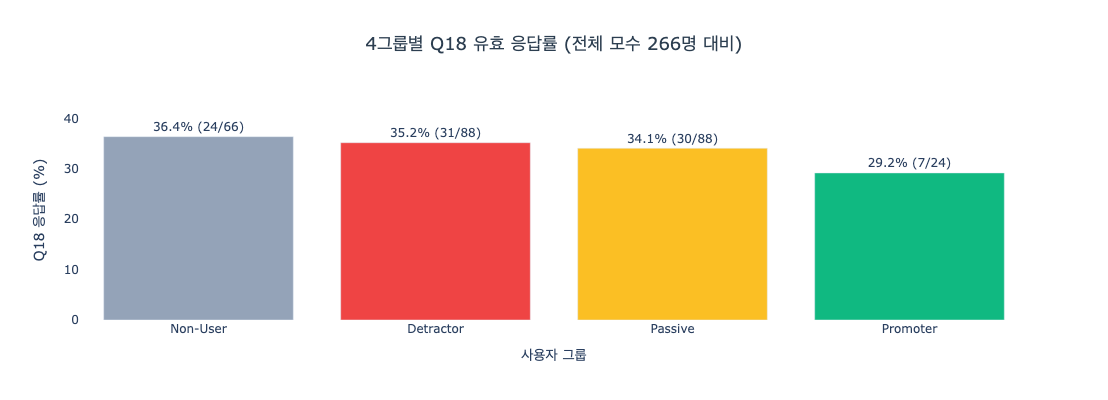

In [8]:
GROUP_COLOR = {'Non-User': '#94A3B8', 'Detractor': '#EF4444', 'Passive': '#FBBF24', 'Promoter': '#10B981'}

fig = go.Figure()
fig.add_trace(go.Bar(
    x=response_rate.index,
    y=response_rate['응답률(%)'],
    text=[f"{r}% ({s}/{t})" for r, s, t in zip(response_rate['응답률(%)'], response_rate['responded'], response_rate['total'])],
    textposition='outside',
    marker_color=[GROUP_COLOR[g] for g in response_rate.index],
))

fig.update_layout(
    title=dict(text=f'4그룹별 Q18 유효 응답률 (전체 모수 {response_rate["total"].sum()}명 대비)',
               x=0.5, xanchor='center', font=dict(size=18, color='#2c3e50')),
    xaxis_title='사용자 그룹',
    yaxis_title='Q18 응답률 (%)',
    yaxis=dict(range=[0, response_rate['응답률(%)'].max() * 1.2]),
    plot_bgcolor='white',
    height=400,
)
fig.show()

In [9]:
df['feedback_length'] = df['feedback'].str.len()

length_stats = (
    df.groupby('user_group')['feedback_length']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reindex(GROUP_ORDER)
    .round(1)
)
length_stats.columns = ['응답수', '평균(자)', '중앙값(자)', '최소(자)', '최대(자)']
length_stats

,응답수,평균(자),중앙값(자),최소(자),최대(자)
user_group,,,,,
Non-User,24,34.5,26.5,2,98
Detractor,31,62.8,30.0,2,673
Passive,30,53.3,28.5,4,478
Promoter,7,63.3,71.0,17,126


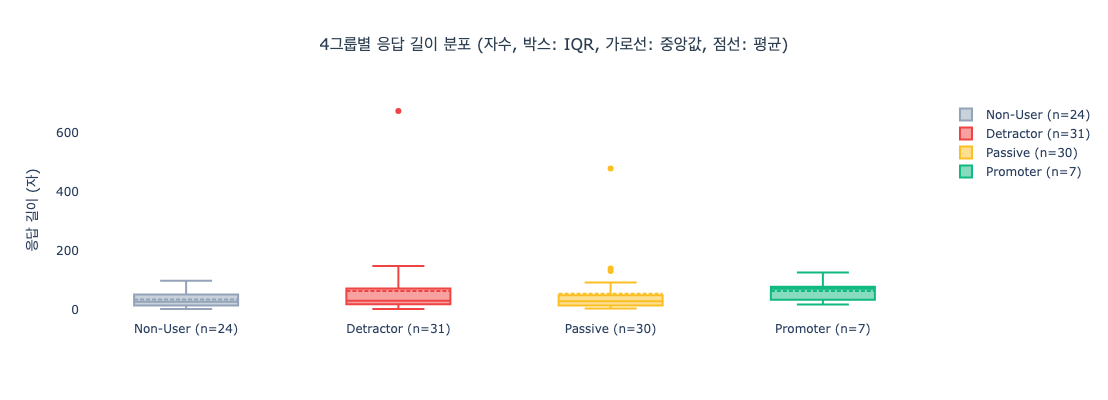

In [10]:
fig = go.Figure()
for grp in GROUP_ORDER:
    fig.add_trace(go.Box(
        y=df[df['user_group'] == grp]['feedback_length'],
        name=f'{grp} (n={len(df[df["user_group"] == grp])})',
        marker_color=GROUP_COLOR[grp],
        boxmean=True,
    ))

fig.update_layout(
    title=dict(text='4그룹별 응답 길이 분포 (자수, 박스: IQR, 가로선: 중앙값, 점선: 평균)',
               x=0.5, xanchor='center', font=dict(size=16, color='#2c3e50')),
    yaxis_title='응답 길이 (자)',
    plot_bgcolor='white',
    height=400,
)
fig.show()

### 관찰 결과 — 그룹별 응답률 29-36%로 비슷, 적극성 차이는 단정 불가
_그룹 라벨 SQL: `response_base` · 집계: pandas_


전체 266명 중 유효 응답은 92명이다.

| 그룹 | 전체 | 유효 응답 | 응답률 |
|---|---:|---:|---:|
| Non-User | 66 | 24 | 36.4% |
| Detractor | 88 | 31 | 35.2% |
| Passive | 88 | 30 | 34.1% |
| Promoter | 24 | 7 | 29.2% |

_(전체 266명 / 유효 응답 92명 기준)_

> ### 섹션 결론
> - 4그룹 응답률은 **29.2-36.4%** 로 차이가 작아, 특정 그룹이 더 적극적으로 응답한다고 단정하기 어렵다.
> - 선택 응답이므로 이후 결과는 그룹 전체의 불만률이 아니라 **유효 자유응답 안의 패턴**으로 한정해 읽는다.

---

## 2. 키워드 빈도 + 워드클라우드
- Q18. (선택) 패션 앱을 사용하면서 아쉬웠던 점이 있다면 자유롭게 적어주세요. (자유응답)

---

Q18 자유응답을 KoNLPy Okt로 명사 추출해 단어 차원의 두 가지 분석을 한 섹션에서 다룬다 — **2-1 키워드 빈도(정량)** 와 **2-2 워드클라우드(시각)**. 이어지는 카테고리 분류(섹션 3) 정량 분석으로 자연스럽게 연결된다.

### 2-1. 키워드 빈도 분석

패션 앱 브랜드명과 의미 약한 일반 명사는 사전·불용어로 보정한다.

In [11]:
# 불용어 사전 (의미 약하거나 분석에 노이즈가 되는 명사)
STOPWORDS = {
    # 의존명사·일반명사
    '때', '경우', '것', '수', '내', '거', '게', '곳', '점', '안', '시', '함', '알', '더', '뿐',
    '등', '다른', '같은', '많은', '여러', '모든', '다양',
    # 부사·관형사 잔여
    '진짜', '너무', '정말', '그냥', '좀', '꽤', '약간', '제일', '가장', '계속', '항상',
    # 대명사·일반어
    '저', '나', '제', '이', '그', '저것', '이것', '그것', '뭐', '무엇', '어디',
    # 양화
    '하나', '둘', '한', '두', '몇',
    # 의미 약함 
    '생각', '느낌', '부분', '사람', '정도',
}

# 1글자 핵심어 화이트리스트 (패션 도메인에서 의미 있는 1글자 명사 — 기본 1글자 필터 우회)
KEEP_ONECHAR = {'옷', '핏', '앱', '홈', '탭', '웹', '키'}

# 사용자 정의 사전 (Okt가 잘못 분리하는 패션 앱 브랜드명·외래어 — 후처리로 통합)
BRAND_MAP = {
    '무신': '무신사', '신사': '무신사',
    '에이블': '에이블리', '에이블리': '에이블리',
    '지그': '지그재그', '지그재그': '지그재그',
    '크림': 'KREAM', 'kream': 'KREAM', 'KREAM': 'KREAM',
    '룩핀': '룩핀',
    '자라': '자라', 'ZARA': '자라',
    '쿠팡': '쿠팡',
    '네이버': '네이버',
    '키오스크': '키오스크',
    '사이즈표': '사이즈표',
    '어플': '앱',
}

# 영문 패션 도메인 키워드 정규식 (Okt가 영문 명사 인식 못함 — 별도 정규식 추출)
EN_KEYWORDS_PATTERN = re.compile(r'\b(UI|UX)\b', re.IGNORECASE)

# 한글 도메인 키워드 정규식 (Okt가 형태소로 잘못 쪼개는 한글 명사 보완)
# 예: "착장하던" → Okt가 ["착", "장하던"]으로 분리해 '착장' 명사 인식 실패
#     "편의성" → Okt가 '편의'로 끊어 '성' 누락
KR_KEYWORDS_PATTERN = re.compile(r'(착장|편의성)')

print(f'불용어: {len(STOPWORDS)}개')
print(f'1글자 화이트리스트: {len(KEEP_ONECHAR)}개')
print(f'브랜드 매핑: {len(BRAND_MAP)}개')
print(f'영문 키워드 정규식: {EN_KEYWORDS_PATTERN.pattern}')
print(f'한글 도메인 정규식: {KR_KEYWORDS_PATTERN.pattern}')

불용어: 54개
1글자 화이트리스트: 7개
브랜드 매핑: 17개
영문 키워드 정규식: \b(UI|UX)\b
한글 도메인 정규식: (착장|편의성)


In [12]:
# Okt 명사 추출 + 불용어 제거 + 브랜드명 통합 + 1글자 핵심어 화이트리스트 + 영문·한글 도메인 정규식
okt = Okt()

def extract_nouns(text, stopwords=STOPWORDS, brand_map=BRAND_MAP,
                  keep_onechar=KEEP_ONECHAR,
                  en_pattern=EN_KEYWORDS_PATTERN, kr_pattern=KR_KEYWORDS_PATTERN):
    if pd.isna(text):
        return []
    text_str = str(text)
    nouns = okt.nouns(text_str)
    cleaned = []
    for n in nouns:
        n_lower = n.lower()
        if n in brand_map:
            cleaned.append(brand_map[n])
        elif n_lower in brand_map:
            cleaned.append(brand_map[n_lower])
        elif n in keep_onechar:
            cleaned.append(n)
        elif n not in stopwords and len(n) >= 2:
            cleaned.append(n)
    # 정규식은 Okt가 놓친 토큰만 보완해 중복 집계를 방지
    for match in en_pattern.findall(text_str):
        normalized = match.upper()
        if normalized not in cleaned:
            cleaned.append(normalized)
    for match in kr_pattern.findall(text_str):
        if match not in cleaned:
            cleaned.append(match)
    return cleaned

df['nouns'] = df['feedback'].apply(extract_nouns)
df[['user_group', 'feedback', 'nouns']].head(10)

,user_group,feedback,nouns
0,Passive,내가 생각했던 내 핏이 아니라서 반품과정이 번거롭다,"[핏, 반품, 과정]"
1,Passive,재고가 없어서 배송이 느린 제품 가끔 존재함,"[재고, 배송, 제품, 가끔, 존재]"
2,Detractor,"무신사 같은 경우에, 수치 기입하는곳은 없고 키와 몸무게? + 연령대로 사이즈와 추...","[수치, 기입, 키, 몸무게, 연령, 사이즈, 추천, 제품, 따라서, 사이즈, 실패..."
3,Detractor,"하나 찾아보면 그거만 보여줌 (ex : 와이드 데님 슬렉스 상품 구경 시, 홈 추천...","[그거, 와이드, 데님, 렉스, 상품, 구경, 홈, 추천, 화면, 거만, 거의, 도..."
4,Non-User,복잡함,[]
5,Detractor,UI/UX 진짜 너무 구림 무신사 << 그냥 맥도날드 키오스크급,"[구림, 맥도날드, 키, 오스, UI, UX]"
6,Detractor,사이즈가 직관적이지않음,"[사이즈, 직관]"
7,Detractor,모델 핏과 다른 옷 핏이나 다른 색감,"[모델, 핏, 옷, 핏, 색감]"
8,Non-User,초보자의 입장에서는 보기 조금 어려운거같음,"[초보자, 입장, 보기, 조금]"
9,Detractor,특가탭에 있는 상품이 일반탭에도 있을 때가 아쉬워유 분명 같은 상품을 담았지만 가격...,"[특가탭, 상품, 탭, 분명, 상품, 가격, 차이, 발생, 결제, 눈치, 나중]"


In [13]:
# 전체 명사 빈도 (상위 20)
all_nouns = [n for nouns_list in df['nouns'] for n in nouns_list]
freq_counter = Counter(all_nouns)

freq_df = pd.DataFrame(freq_counter.most_common(20), columns=['키워드', '빈도'])
freq_df

,키워드,빈도
0,사이즈,26
1,옷,20
2,리뷰,17
3,앱,15
4,상품,13
5,실제,12
6,사진,11
7,체형,10
8,구매,10
9,핏,9


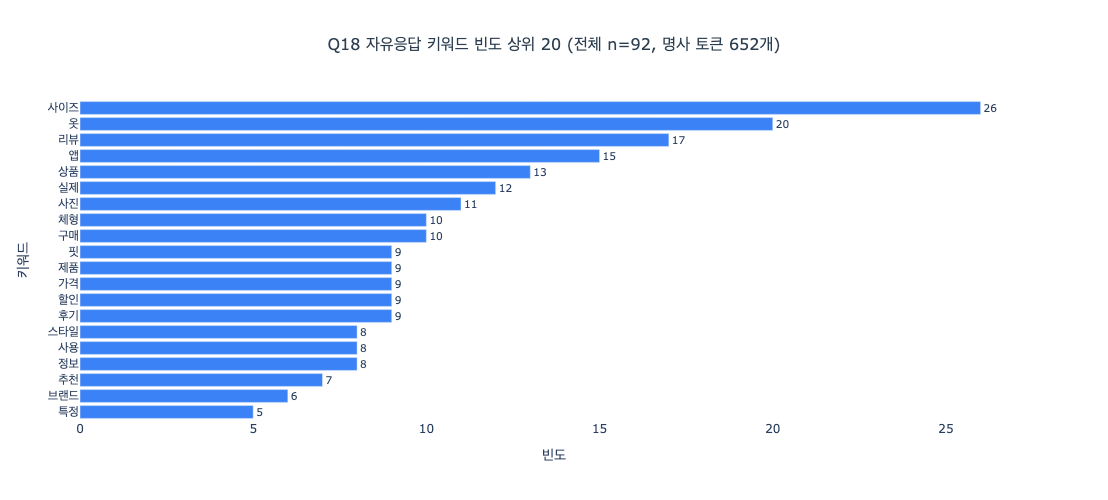

In [14]:
fig = go.Figure(go.Bar(
    x=freq_df['빈도'][::-1],
    y=freq_df['키워드'][::-1],
    orientation='h',
    text=freq_df['빈도'][::-1],
    textposition='outside',
    marker_color='#3B82F6',
))

fig.update_layout(
    title=dict(text=f'Q18 자유응답 키워드 빈도 상위 20 (전체 n={len(df)}, 명사 토큰 {len(all_nouns)}개)',
               x=0.5, xanchor='center', font=dict(size=16, color='#2c3e50')),
    xaxis_title='빈도',
    yaxis_title='키워드',
    plot_bgcolor='white',
    height=500,
    margin=dict(l=80),
)
fig.show()

In [15]:
# 그룹별 키워드 빈도 상위 10 (Detractor vs Non-User 중심 비교)
group_freq = {}
for grp in GROUP_ORDER:
    grp_nouns = [n for nouns_list in df[df['user_group'] == grp]['nouns'] for n in nouns_list]
    group_freq[grp] = Counter(grp_nouns).most_common(10)

# 비교 표
max_len = max(len(v) for v in group_freq.values())
compare_df = pd.DataFrame({
    grp: [f"{w} ({c})" if i < len(group_freq[grp]) else '' 
          for i, (w, c) in enumerate(group_freq[grp] + [('', 0)] * (max_len - len(group_freq[grp])))]
    for grp in GROUP_ORDER
})
compare_df.index = [f'{i+1}위' for i in range(len(compare_df))]
compare_df

,Non-User,Detractor,Passive,Promoter
1위,옷 (5),사이즈 (11),옷 (9),앱 (4)
2위,실제 (5),상품 (8),사이즈 (9),후기 (4)
3위,사이즈 (4),스타일 (6),리뷰 (6),리뷰 (3)
4위,사용 (3),옷 (6),제품 (4),기준 (2)
5위,앱 (3),할인 (6),특정 (4),사이즈 (2)
6위,구매 (3),추천 (5),체형 (4),사진 (2)
7위,리뷰 (3),사진 (5),브랜드 (4),상품 (2)
8위,가격 (2),앱 (5),사진 (4),실제 (2)
9위,예상 (2),리뷰 (5),어려움 (4),정보 (2)
10위,모름 (2),구경 (4),핏 (3),체중 (2)


### 관찰 결과 — 사이즈·옷·리뷰가 상위 키워드
_형태소·빈도: pandas/KoNLPy(Okt) · SQL 부적합_


사이즈 26회, 옷 20회, 리뷰 17회, 앱 15회, 상품 13회 순이다. 반복을 포함한 토큰 횟수이므로 탐색 자료로만 사용하며 그룹 간 강도를 직접 비교하지 않는다.

### 2-2. 전체 워드클라우드

전체 키워드 빈도는 보조 자료로 살펴본다. 정확한 비교는 빈도표와 응답자 기준 카테고리 집계로 한다.

In [16]:
import sys

KOREAN_FONT = os.getenv('FONT_PATH')

if not KOREAN_FONT or not os.path.exists(KOREAN_FONT):
    if sys.platform == 'darwin':
        KOREAN_FONT = '/System/Library/Fonts/AppleSDGothicNeo.ttc'
    elif sys.platform.startswith('linux'):
        KOREAN_FONT = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    elif sys.platform == 'win32':
        KOREAN_FONT = 'C:/Windows/Fonts/malgun.ttf'

    if not os.path.exists(KOREAN_FONT):
        KOREAN_FONT = fm.findfont(fm.FontProperties(family='sans-serif'))
        print(f'⚠️ 한글 폰트 미발견 → 영문 fallback ({KOREAN_FONT}) — 워드클라우드 한글 깨질 수 있음')

def make_wordcloud(freq_dict, title, ax, width=600, height=400):
    wc = WordCloud(
        font_path=KOREAN_FONT,
        background_color='white',
        width=width,
        height=height,
        max_words=50,
        colormap='viridis',
        relative_scaling=0.4,
        random_state=42,
    ).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, color='#2c3e50')
    ax.axis('off')

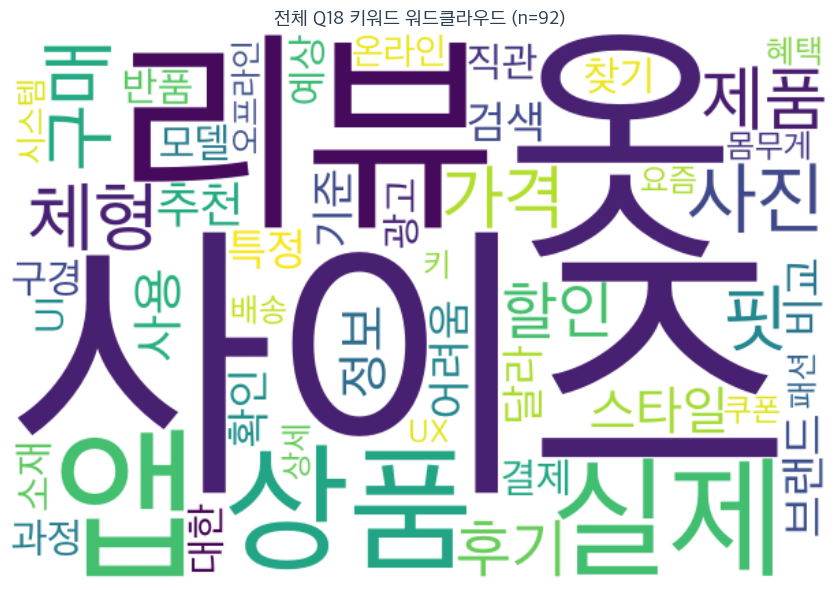

In [17]:
# 전체 워드클라우드
fig, ax = plt.subplots(figsize=(10, 6))
make_wordcloud(dict(freq_counter), f'전체 Q18 키워드 워드클라우드 (n={len(df)})', ax)
plt.tight_layout()
plt.show()

워드클라우드는 새로운 검증 자료가 아니므로 그룹별 그림은 제거하고 전체 그림 하나만 보조로 남겼다. 정확한 비교는 빈도표(2-1)와 응답자 기준 카테고리 집계(섹션 3)를 사용한다.

> ### 섹션 결론
> - 상위 키워드는 사이즈·옷·리뷰로, 사이즈/핏 관련어가 가장 크게 나타난다.
> - 키워드 빈도는 반복 토큰 기반이라 탐색용이며, 응답자 기준 강도 비교는 다음 섹션의 카테고리 집계로 확인한다.

---

## 3. 수동 카테고리 분류
- Q18. (선택) 패션 앱을 사용하면서 아쉬웠던 점이 있다면 자유롭게 적어주세요. (자유응답)

---

키워드 빈도와 워드클라우드로 본 패턴을 더 구체적인 불만 영역으로 묶기 위해 응답을 **8개 카테고리**로 분류한다.

**분류 방식 — 자동 1차 분류 + 원문 전수 감사**
1. 카테고리별 키워드·문맥 정규식으로 `auto_categories` 1차 라벨 생성
2. 유효 응답 92건 원문을 모두 읽고 다중 라벨을 수동 판정
3. 최종 분석은 `AUDITED_LABELS`를 사용하며, 자동 라벨은 감사·재현 보조 자료로만 유지
4. 자동 라벨과 최종 라벨이 달랐던 9건은 검증 셀에서 전수 출력

| 카테고리 | 키워드 예시 |
|---|---|
| **사이즈/핏** | 사이즈·핏·체형·치수·사이즈표·실측 |
| **정보/리뷰** | 리뷰·사진·후기·정보·실물·디테일 |
| **추천/검색** | 추천·알고리즘·필터·검색·디자인·비슷·스타일 |
| **UI/UX** | UI·UX·앱·복잡·메뉴·인터페이스·홈·탭 |
| **가격/혜택** | 가격·할인·쿠폰·결제·적립·비용 |
| **배송/반품** | 배송·반품·교환·반품비 |
| **재고/품질** | 재고·품질·재질·소재 |
| **광고/마케팅** | 광고·팝업·메일 |

In [18]:
# 카테고리 키워드 사전 (8개) — 자동 1차 라벨 생성용
CATEGORY_KEYWORDS = {
    '사이즈/핏':   {'사이즈', '핏', '체형', '치수', '몸무게', '사이즈표', '실착',
                  '빅사', '착장', 'size',
                  '신장', '체중', '단면', '가슴', '밑위', '기장', '라인감'},
    '정보/리뷰':   {'리뷰', '사진', '후기', '정보', '이미지', '실물', '디테일',
                  '색감', '색상', '질감', '상세', '페이지', '모델',
                  '별점', '조명', '보정', '촬영', '체험', '체형별', '일반인'},
    '추천/검색':   {'추천', '알고리즘', '필터', '검색', '카테고리', '랭킹',
                  '연관', '나열', '맞춤', '취향'},
    'UI/UX':      {'UI', 'UX', '복잡', '인터페이스', '메뉴', '버벅거림',
                  'webview', '키오스크', '편의', '편의성', '로그인'},
    '가격/혜택':   {'가격', '할인', '쿠폰', '적립', '혜택', '포인트', '특가'},
    '배송/반품':   {'배송', '반품', '교환', '반품비', '환불'},
    '재고/품질':   {'재고', '품질', '재질', '소재', '원단', '퀄리티', '박음질'},
    '광고/마케팅': {'광고', '팝업', '메일'},
}

# 일반 단어는 단독 키워드 대신 문맥이 드러나는 구문으로만 분류
CATEGORY_PATTERNS = {
    '사이즈/핏': [
        r'(실제|예상).{0,8}(핏|사이즈|착용)',
        r'(입어|착용).{0,8}(볼 수 없|못|어렵)',
        r'사이즈.{0,10}(측정|정보|표기).{0,8}(없|부족|어렵)',
        r'(입었을|입을).{0,10}(상상|예상).{0,8}(안|어렵|힘들)',
    ],
    '추천/검색': [
        r'비슷한.{0,6}(스타일|옷)', r'(같은|똑같은).{0,8}(추천|보여)',
        r'(특정|비슷한).{0,8}(것|상품|옷).{0,8}(보여|나오)',
        r'(원하는|맞는).{0,12}(옷|디자인|스타일|상품).{0,16}(찾|모르|없|힘들|어렵)',
        r'(옷|상품).{0,8}(분류|기준).{0,8}(더|많)',
        r'(어디|어느).{0,12}(파는|판매).{0,8}(모르|모를|찾)',
    ],
    'UI/UX': [
        r'(앱|어플|화면|홈|탭|메뉴).{0,12}(복잡|불편|어렵|어려|버벅|직관)',
        r'(복잡|불편|어렵|어려|버벅|직관).{0,12}(앱|어플|화면|홈|탭|메뉴)',
        r'초보자.{0,40}(복잡|불편|어렵|어려|직관)', r'키오스크',
    ],
}

# 자동 분류가 잡지 못한 응답 수동 라벨링 (raw text 직접 검토 후 부여)
MANUAL_LABELS = {
    '복잡함': ['UI/UX'],
    '너무 비슷한 옷이 많아 뭐가다른지 모름': ['추천/검색'],
}

def classify_response(row):
    raw = str(row['feedback']).strip()
    nouns_set = set(row['nouns'])
    raw_lower = raw.lower()
    cats = set()
    for cat, kws in CATEGORY_KEYWORDS.items():
        # 1차: 명사 매칭
        if nouns_set & kws:
            cats.add(cat)
            continue
        # 2차: 영문 키워드는 단어 경계 기준으로만 매칭
        for k in kws:
            if k.isascii() and re.search(
                rf'(?<![A-Za-z0-9_]){re.escape(k.lower())}(?![A-Za-z0-9_])',
                raw_lower,
            ):
                cats.add(cat)
                break
    # 3차: 일반 단어는 문맥 정규식으로 보완
    for cat, patterns in CATEGORY_PATTERNS.items():
        if any(re.search(pattern, raw_lower) for pattern in patterns):
            cats.add(cat)
    # 수동 라벨은 자동 라벨을 대체하지 않고 보완
    cats.update(MANUAL_LABELS.get(raw, []))
    return sorted(cats) if cats else ['미분류']

df['auto_categories'] = df.apply(classify_response, axis=1)

# 92건 원문 전수 감사 후 확정한 최종 라벨 (user_id 기준, 다중 라벨 허용)
AUDITED_LABELS = {
    1: ['배송/반품', '사이즈/핏'],
    2: ['배송/반품', '재고/품질'],
    4: ['사이즈/핏', '추천/검색'],
    6: ['추천/검색'],
    7: ['UI/UX'],
    8: ['UI/UX'],
    9: ['사이즈/핏'],
    12: ['사이즈/핏', '정보/리뷰'],
    15: ['UI/UX'],
    17: ['가격/혜택'],
    18: ['UI/UX'],
    22: ['가격/혜택'],
    23: ['광고/마케팅'],
    26: ['추천/검색'],
    33: ['UI/UX'],
    34: ['UI/UX', '사이즈/핏'],
    39: ['추천/검색'],
    42: ['사이즈/핏'],
    43: ['추천/검색'],
    44: ['UI/UX'],
    45: ['배송/반품'],
    46: ['가격/혜택'],
    48: ['추천/검색'],
    50: ['사이즈/핏', '정보/리뷰'],
    51: ['가격/혜택', '추천/검색'],
    58: ['배송/반품', '사이즈/핏'],
    59: ['사이즈/핏', '추천/검색'],
    62: ['UI/UX', '가격/혜택'],
    63: ['가격/혜택'],
    67: ['가격/혜택', '사이즈/핏', '재고/품질', '정보/리뷰'],
    68: ['추천/검색'],
    70: ['UI/UX', '추천/검색'],
    73: ['광고/마케팅'],
    76: ['사이즈/핏'],
    77: ['UI/UX'],
    79: ['사이즈/핏'],
    80: ['추천/검색'],
    81: ['정보/리뷰'],
    87: ['UI/UX'],
    88: ['추천/검색'],
    90: ['정보/리뷰'],
    92: ['정보/리뷰'],
    94: ['추천/검색'],
    95: ['사이즈/핏', '정보/리뷰'],
    96: ['사이즈/핏', '정보/리뷰'],
    98: ['가격/혜택'],
    100: ['재고/품질'],
    101: ['가격/혜택'],
    104: ['광고/마케팅'],
    110: ['사이즈/핏', '재고/품질', '정보/리뷰'],
    112: ['사이즈/핏', '정보/리뷰'],
    115: ['정보/리뷰'],
    120: ['사이즈/핏', '정보/리뷰'],
    125: ['광고/마케팅', '사이즈/핏', '재고/품질', '정보/리뷰', '추천/검색'],
    127: ['추천/검색'],
    128: ['정보/리뷰', '추천/검색'],
    137: ['사이즈/핏'],
    146: ['사이즈/핏'],
    155: ['사이즈/핏'],
    159: ['사이즈/핏'],
    160: ['가격/혜택'],
    170: ['사이즈/핏'],
    171: ['사이즈/핏'],
    174: ['가격/혜택'],
    177: ['사이즈/핏'],
    183: ['추천/검색'],
    185: ['추천/검색'],
    188: ['사이즈/핏'],
    194: ['사이즈/핏', '정보/리뷰'],
    196: ['재고/품질', '정보/리뷰'],
    197: ['사이즈/핏', '재고/품질', '정보/리뷰'],
    198: ['재고/품질', '정보/리뷰'],
    206: ['가격/혜택'],
    207: ['사이즈/핏'],
    208: ['사이즈/핏'],
    212: ['배송/반품', '사이즈/핏'],
    224: ['추천/검색'],
    226: ['가격/혜택'],
    228: ['사이즈/핏'],
    231: ['UI/UX'],
    233: ['사이즈/핏', '정보/리뷰'],
    234: ['추천/검색'],
    235: ['추천/검색'],
    240: ['사이즈/핏'],
    243: ['사이즈/핏'],
    249: ['사이즈/핏', '정보/리뷰', '추천/검색'],
    253: ['광고/마케팅'],
    255: ['추천/검색'],
    256: ['사이즈/핏'],
    257: ['배송/반품', '사이즈/핏', '정보/리뷰'],
    258: ['배송/반품', '사이즈/핏', '추천/검색'],
    262: ['가격/혜택'],
}

audit_ids = set(AUDITED_LABELS)
data_ids = set(df['user_id'])
assert audit_ids == data_ids, (
    f'전수 감사 라벨 불일치 — 누락: {sorted(data_ids - audit_ids)}, ' 
    f'불필요: {sorted(audit_ids - data_ids)}'
)
df['categories'] = df['user_id'].map(AUDITED_LABELS).apply(sorted)
df[['user_group', 'feedback', 'auto_categories', 'categories']].head(5)

,user_group,feedback,auto_categories,categories
0,Passive,내가 생각했던 내 핏이 아니라서 반품과정이 번거롭다,"[배송/반품, 사이즈/핏]","[배송/반품, 사이즈/핏]"
1,Passive,재고가 없어서 배송이 느린 제품 가끔 존재함,"[배송/반품, 재고/품질]","[배송/반품, 재고/품질]"
2,Detractor,"무신사 같은 경우에, 수치 기입하는곳은 없고 키와 몸무게? + 연령대로 사이즈와 추...","[사이즈/핏, 추천/검색]","[사이즈/핏, 추천/검색]"
3,Detractor,"하나 찾아보면 그거만 보여줌 (ex : 와이드 데님 슬렉스 상품 구경 시, 홈 추천...",[추천/검색],[추천/검색]
4,Non-User,복잡함,[UI/UX],[UI/UX]


In [19]:
# 분류 결과 검증 (미분류·다중 매칭 분포)
unclassified = df[df['categories'].apply(lambda x: x == ['미분류'])]
multi_dist = df['categories'].apply(len).value_counts().sort_index()

print(f'전체 응답: {len(df)}')
print(f'분류 완료: {len(df) - len(unclassified)}명 ({(len(df) - len(unclassified))/len(df)*100:.1f}%)')
print(f'미분류: {len(unclassified)}명 ({len(unclassified)/len(df)*100:.1f}%)')
print()
print('=== 카테고리 다중 매칭 분포 ===')
for n, c in multi_dist.items():
    pct = c / len(df) * 100
    print(f'  {n}개 카테고리 매칭: {c:3d}명 ({pct:.1f}%)')

# 미분류 raw 출력 — 향후 사전 확장 시 즉시 패턴 확인 가능 (현재 0건이면 빈 결과)
if len(unclassified) > 0:
    print('\n=== 미분류 응답 전수 (MANUAL_LABELS 사전 확장 후보) ===')
    for _, r in unclassified.iterrows():
        print(f'  [{r.user_group}] "{r.feedback}"')
else:
    print('\n✓ 미분류 0건 — 분류 커버리지 100% (정확도 검증과는 별개)')

# 과다 분류 가능성이 높은 응답 전수 감사
high_multilabel = df[df['categories'].apply(len) >= 3]
print('=' * 60)
print(f'3개 이상 카테고리 매칭 응답 ({len(high_multilabel)}건)')
print('=' * 60 + '\n')
for _, r in high_multilabel.iterrows():
    print(f'[{r.user_group}] {r.categories}')
    print(f'"{r.feedback}"')
    print('-' * 60)

print()  # 섹션 간 빈 줄

# 자동 라벨과 전수 감사 최종 라벨의 차이 확인
label_changes = df[df.apply(lambda r: r['auto_categories'] != r['categories'], axis=1)]
print('=' * 60)
print(f'자동 → 전수 감사 라벨 변경 ({len(label_changes)}건)')
print('=' * 60 + '\n')
for _, r in label_changes.sort_values('user_id').iterrows():
    print(f'ID={r.user_id}: {r.auto_categories} → {r.categories}')

전체 응답: 92
분류 완료: 92명 (100.0%)
미분류: 0명 (0.0%)

=== 카테고리 다중 매칭 분포 ===
  1개 카테고리 매칭:  64명 (69.6%)
  2개 카테고리 매칭:  21명 (22.8%)
  3개 카테고리 매칭:   5명 (5.4%)
  4개 카테고리 매칭:   1명 (1.1%)
  5개 카테고리 매칭:   1명 (1.1%)

✓ 미분류 0건 — 분류 커버리지 100% (정확도 검증과는 별개)
3개 이상 카테고리 매칭 응답 (7건)

[Passive] ['가격/혜택', '사이즈/핏', '재고/품질', '정보/리뷰']
"1. 내가 받을수있는 최대 혜택의 할인을 일일히 찾아봐야 하는것이 불편했음. 

2. 특정 브랜드마다 평소 착장하던 사이즈보다 작거나 큰경우가 있음.

3. 필자는 구매시 의류의 소재를 중요시함. 보통 리뷰나 상세정보에서는 소재에 관해 직접적으로 체험해보거나 사실적인 사진을 찾기힘듬. 하지만 그렇다고 오프라인 스토어를 돌아다니긴 귀찮음...
이 부분을 개선할 수 있는 시스템이 있으면 좋을듯.
Ex: 소재의 파츠를 소량 배송 받아볼수있는 시스템

4. 동일한 체형, 신장이여도 사람별로 라인감, 기장의 느낌이 다르다고 생각함.
 이러한 문제를 해결하기위해 무신사는 현재 리뷰에서 내가 설정해둔 동일한 체형의 사람의 리뷰를 볼수있게 제공하고있음. 하지만 요즘 무신사의 리뷰를 보면 대다수 포인트 적립의 목적성이 강한 대충 촬영한 리뷰 사진이 가득함. 이러한 리뷰는 오히려 악영향을 미친다고 생각함. 이 부분을 해결할 새로운 방향성을 제시해주면 좋을듯 함."
------------------------------------------------------------
[Passive] ['사이즈/핏', '재고/품질', '정보/리뷰']
"상세 페이지에 사진이 제대로 안 보여서 옷 재질이나 핏을 제대로 볼수없음"
------------------------------------------------------------
[Detrac

In [20]:
# 카테고리별 응답 수 (다중 매칭 허용)
cat_count = Counter()
for cats in df['categories']:
    for c in cats:
        if c != '미분류':
            cat_count[c] += 1

cat_df = pd.DataFrame(cat_count.most_common(), columns=['카테고리', '응답 수'])
cat_df['비율(%)'] = (cat_df['응답 수'] / len(df) * 100).round(1)
cat_df

,카테고리,응답 수,비율(%)
0,사이즈/핏,39,42.4
1,추천/검색,24,26.1
2,정보/리뷰,21,22.8
3,가격/혜택,14,15.2
4,UI/UX,12,13.0
5,재고/품질,8,8.7
6,배송/반품,7,7.6
7,광고/마케팅,5,5.4


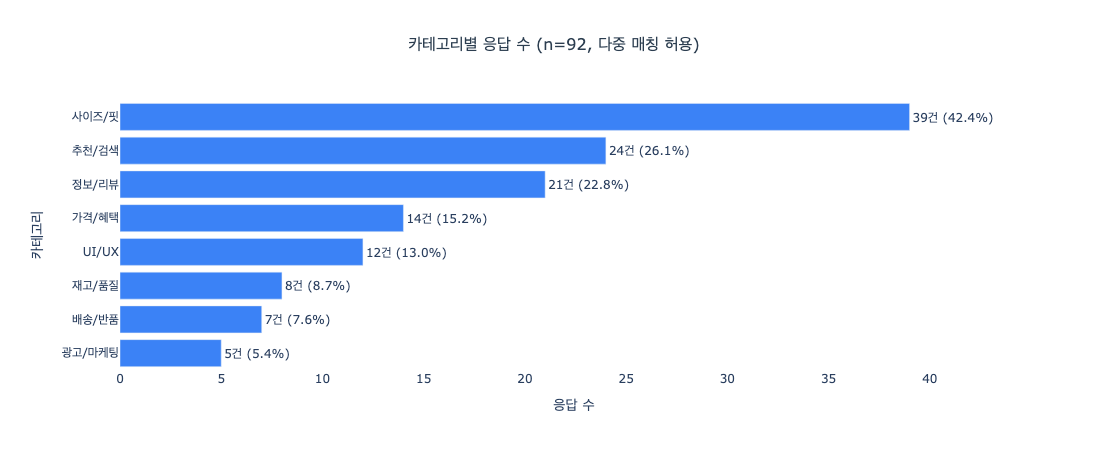

In [21]:
max_val = cat_df['응답 수'].max() * 1.15

fig = go.Figure(go.Bar(
    x=cat_df['응답 수'][::-1],
    y=cat_df['카테고리'][::-1],
    orientation='h',
    text=[f'{n}건 ({p}%)' for n, p in zip(cat_df['응답 수'][::-1], cat_df['비율(%)'][::-1])],
    textposition='outside',
    marker_color='#3B82F6',
    cliponaxis=False # 텍스트가 플롯 영역 밖으로 나가도 잘리지 않도록 방지
))

fig.update_layout(
    title=dict(text=f'카테고리별 응답 수 (n={len(df)}, 다중 매칭 허용)',
               x=0.5, xanchor='center', font=dict(size=16, color='#2c3e50')),
    xaxis=dict(
        title='응답 수',
        range=[0, max_val] # X축 우측에 빈 공간을 인위적으로 확보
    ),
    yaxis_title='카테고리',
    plot_bgcolor='white',
    height=450,
    margin=dict(l=120),
)
fig.show()

> **대표 사례** — 사이즈표 기준 불일치, 반복 추천, 사진과 실물 차이, 제한적인 쿠폰 적용, 불편한 UI/UX 등이 나타났다. 인용은 표현 예시이며 대표성을 의미하지 않는다.

### 관찰 결과 — 사이즈/핏·추천/검색·정보/리뷰가 상위 3 카테고리
_카테고리 분류·집계: pandas (DB 비파생) · SQL 부적합_


| 카테고리 | 응답 수 | 비율 |
|---|---:|---:|
| 사이즈/핏 | 39 | 42.4% |
| 추천/검색 | 24 | 26.1% |
| 정보/리뷰 | 21 | 22.8% |
| 가격/혜택 | 14 | 15.2% |
| UI/UX | 12 | 13.0% |
| 재고/품질 | 8 | 8.7% |
| 배송/반품 | 7 | 7.6% |
| 광고/마케팅 | 5 | 5.4% |

_(유효 응답 92건, 다중 라벨 허용 — 비율 합 100% 초과)_

> ### 섹션 결론
> - 사이즈/핏 **42.4%(39건)** 이 최대 불만 영역이고, 추천/검색·정보/리뷰가 뒤를 잇는다.
> - 92건을 원문 전수 감사했으며(단일 64·이중 21·3개 이상 7건, 평균 1.41개), 자동·최종 라벨이 달랐던 9건을 수정했다. 다만 수동 판단이 포함되어 일부 응답은 다르게 분류될 수 있다.

---

## 4. NPS 세그먼트 × 카테고리
- Q18. (선택) 패션 앱 사용 중 아쉬웠던 점 (자유응답) · Q15. 추천점수(NPS 세그먼트 분류)

---

**분석 질문 1** — Detractor의 카테고리 분포는 나머지 그룹과 다른가?

- 근거: `03_nps` 발견 4("Detractor 이탈 요인 Q13 분포는 전체와 거의 동일")는 단일응답(Q13) 기준 정량 분석이었다. 자유응답 정성 데이터로 같은 분석을 보완한다.
- 분석 방법: 그룹별 카테고리 비율 + 해당 그룹을 제외한 나머지 응답자 대비 편차(%p) 비교 (다중응답이라 검정 부적합, 기술통계)
- 분석 대상: 유효 응답 92명 (Detractor 31 / Passive 30 / Non-User 24 / Promoter 7)
- 해석 기준: 편차는 탐색적 신호이며 통계적으로 검증된 차이가 아님. Promoter n=7은 사례 수준으로만 해석

In [22]:
# 그룹 × 카테고리 응답 수 매트릭스 (다중 매칭 허용)
CAT_ORDER = ['사이즈/핏', 'UI/UX', '추천/검색', '정보/리뷰', '가격/혜택', '배송/반품', '광고/마케팅', '재고/품질']

group_sizes = df['user_group'].value_counts().reindex(GROUP_ORDER)

cross_mat = pd.DataFrame(0, index=GROUP_ORDER, columns=CAT_ORDER)
for _, row in df.iterrows():
    for c in row['categories']:
        if c in CAT_ORDER:
            cross_mat.loc[row['user_group'], c] += 1

cross_mat

,사이즈/핏,UI/UX,추천/검색,정보/리뷰,가격/혜택,배송/반품,광고/마케팅,재고/품질
Non-User,11,5,7,6,2,1,1,1
Detractor,13,4,10,6,7,3,1,2
Passive,12,3,6,4,5,3,2,5
Promoter,3,0,1,5,0,0,1,0


In [23]:
# 그룹 × 카테고리 비율 (각 그룹 응답자 수 대비, %)
cross_pct = (cross_mat.div(group_sizes, axis=0) * 100).round(1)
cross_pct

,사이즈/핏,UI/UX,추천/검색,정보/리뷰,가격/혜택,배송/반품,광고/마케팅,재고/품질
Non-User,45.8,20.8,29.2,25.0,8.3,4.2,4.2,4.2
Detractor,41.9,12.9,32.3,19.4,22.6,9.7,3.2,6.5
Passive,40.0,10.0,20.0,13.3,16.7,10.0,6.7,16.7
Promoter,42.9,0.0,14.3,71.4,0.0,0.0,14.3,0.0


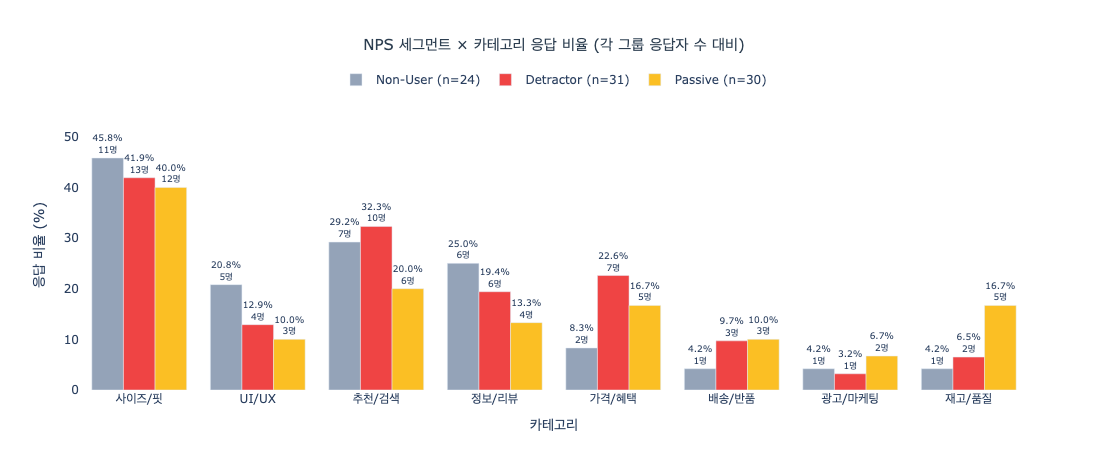

In [24]:
# 그룹 × 카테고리 비율 — 세로 그룹 막대 (Promoter n=7은 표본이 작아 막대에서 분리, 사례로만 해석)
MAIN_GROUPS = ['Non-User', 'Detractor', 'Passive']

fig = go.Figure()
for grp in MAIN_GROUPS:
    fig.add_trace(go.Bar(
        name=f'{grp} (n={group_sizes[grp]})',
        x=CAT_ORDER,
        y=cross_pct.loc[grp],
        text=[f'{cross_pct.loc[grp, c]}%<br>{cross_mat.loc[grp, c]}명' for c in CAT_ORDER],
        textposition='outside',
        textfont=dict(size=9),
        marker_color=GROUP_COLOR[grp],
    ))

fig.update_layout(
    title=dict(text='NPS 세그먼트 × 카테고리 응답 비율 (각 그룹 응답자 수 대비)',
               x=0.5, xanchor='center', font=dict(size=15, color='#2c3e50')),
    xaxis_title='카테고리', yaxis_title='응답 비율 (%)',
    barmode='group',
    yaxis=dict(range=[0, cross_pct.loc[MAIN_GROUPS].values.max() * 1.25]),
    plot_bgcolor='white', height=470,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
)
fig.show()

In [25]:
# 그룹별 비율을 해당 그룹을 제외한 나머지 응답자와 비교
overall_pct = (cross_mat.sum(axis=0) / len(df) * 100).round(1)
rest_pct = pd.DataFrame(index=GROUP_ORDER, columns=CAT_ORDER, dtype=float)
for grp in GROUP_ORDER:
    rest_counts = cross_mat.drop(index=grp).sum(axis=0)
    rest_n = group_sizes.drop(index=grp).sum()
    rest_pct.loc[grp] = rest_counts / rest_n * 100

one_vs_rest_diff = (cross_pct - rest_pct).round(1)
one_vs_rest_diff

,사이즈/핏,UI/UX,추천/검색,정보/리뷰,가격/혜택,배송/반품,광고/마케팅,재고/품질
Non-User,4.6,10.5,4.2,2.9,-9.3,-4.6,-1.7,-6.1
Detractor,-0.7,-0.2,9.3,-5.2,11.1,3.1,-3.4,-3.3
Passive,-3.5,-4.5,-9.0,-14.1,2.2,3.5,1.9,11.9
Promoter,0.5,-14.1,-12.8,52.6,-16.5,-8.2,9.6,-9.4


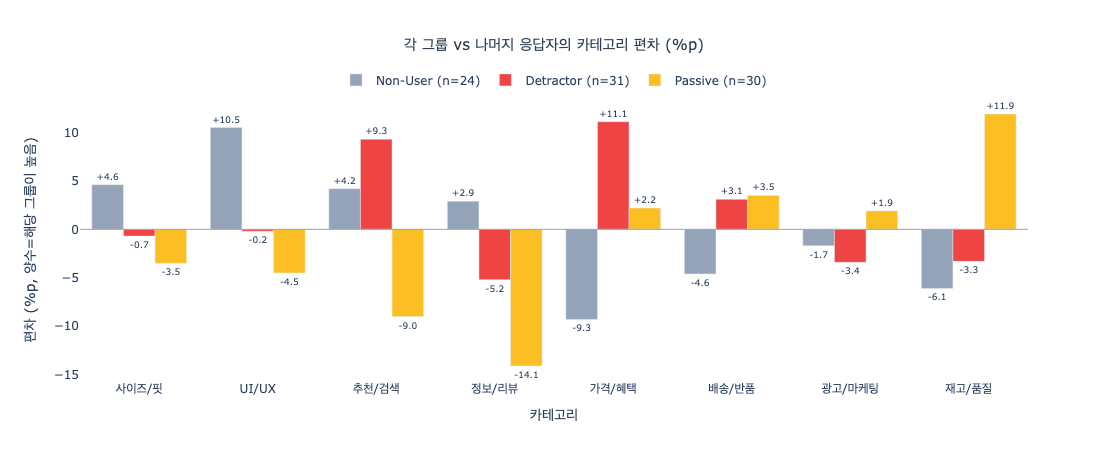

In [26]:
# 각 그룹 vs 나머지 응답자 카테고리 편차(%p) — 세로 그룹 막대
fig = go.Figure()
for grp in MAIN_GROUPS:
    fig.add_trace(go.Bar(
        name=f'{grp} (n={group_sizes[grp]})',
        x=CAT_ORDER,
        y=one_vs_rest_diff.loc[grp],
        text=[f'{one_vs_rest_diff.loc[grp, c]:+.1f}' for c in CAT_ORDER],
        textposition='outside',
        textfont=dict(size=9),
        marker_color=GROUP_COLOR[grp],
    ))

fig.update_layout(
    title=dict(text='각 그룹 vs 나머지 응답자의 카테고리 편차 (%p)',
               x=0.5, xanchor='center', font=dict(size=15, color='#2c3e50')),
    xaxis_title='카테고리', yaxis_title='편차 (%p, 양수=해당 그룹이 높음)',
    barmode='group', plot_bgcolor='white', height=460,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
)
fig.add_hline(y=0, line_width=1, line_color='#9ca3af')
fig.show()

In [27]:
# 그룹별 상위 3 카테고리 비교 — Detractor와 전체 패턴이 같은지 시각화
top3_records = []
for grp in GROUP_ORDER:
    top3 = cross_mat.loc[grp].sort_values(ascending=False).head(3)
    n = group_sizes[grp]
    for rank, (cat, cnt) in enumerate(top3.items(), 1):
        top3_records.append({
            '그룹': grp, '순위': f'{rank}위', '카테고리': cat,
            '응답수': cnt, '비율(%)': round(cnt / n * 100, 1),
        })
top3_df = pd.DataFrame(top3_records)
top3_pivot = top3_df.pivot(index='그룹', columns='순위', values='카테고리').reindex(GROUP_ORDER)
top3_pivot.columns.name = None
top3_pivot

,1위,2위,3위
그룹,,,
Non-User,사이즈/핏,추천/검색,정보/리뷰
Detractor,사이즈/핏,추천/검색,가격/혜택
Passive,사이즈/핏,추천/검색,가격/혜택
Promoter,정보/리뷰,사이즈/핏,추천/검색


> **Promoter 사례(n=7)** — 정보/리뷰 5명(71.4%), 사이즈/핏 3명(42.9%)이다. n=7로 표본이 매우 작아 비율은 참고용으로만 보고, 사례 수준으로만 해석한다.

### 분석 질문 1 결과: 특수 집중은 약함, 가격·추천만 탐색적 신호
_교차: pandas (카테고리 파생) · SQL 부적합_


Detractor는 사이즈/핏 41.9%, 추천/검색 32.3%, 가격/혜택 22.6% 순이다. 나머지 그룹 대비 사이즈/핏 -0.7%p, 가격/혜택 +11.1%p, 추천/검색 +9.3%p로, 1위 사이즈/핏은 다른 그룹과 같고 가격·추천에서만 약한 편차가 보인다.

> ### 섹션 결론
> - Detractor 1위는 사이즈/핏(41.9%)으로 다른 그룹과 같아, 하나의 특수 불만에 집중됐다고 보기는 어렵다.
> - 가격/혜택 **+11.1%p**, 추천/검색 **+9.3%p** 만 나머지보다 높지만, 작은 표본의 탐색적 신호이지 통계적으로 검증된 차이는 아니다.
> - `03_nps` 발견 4(Q13 기준 "Detractor 분포 ≈ 전체")와 같은 방향으로, 자유응답에서도 특수성은 약하게 나타난다.

---

## 5. Non-User 미진입·이탈 사유
- Q18. (선택) 패션 앱 사용 중 아쉬웠던 점 (자유응답) · Q5. 패션 앱 사용 여부

---

**분석 질문 2** — Non-User의 사유는 사용자 그룹과 어떻게 다른가?

- 근거: 03-06 노트북은 Non-User를 제외하거나 부분적으로만 다뤘다(Q15 NPS·Q9 구매 빈도가 Non-User엔 미정의). Q18 자유응답만 가능한 Non-User 직접 진술을 단독 분석한다.
- 분석 방법: Non-User(n=24) vs 사용자 3그룹 합산(n=68) 카테고리 편차(%p) + 명시적 이탈/미진입/비대면 장벽 시그널 추출 + 인구통계 프로파일
- 분석 대상: Non-User 유효 응답자 24명
- 해석 기준: 편차·시그널은 탐색적 신호이며, 인구통계는 응답자 프로파일일 뿐 전체 Non-User 특성이 아님

In [28]:
# Non-User vs 사용자 통합(Detractor + Passive + Promoter 합산) 카테고리 비교
USER_GROUPS = ['Detractor', 'Passive', 'Promoter']
user_n = group_sizes[USER_GROUPS].sum()
non_n = group_sizes['Non-User']

user_cnt = cross_mat.loc[USER_GROUPS].sum(axis=0)
non_cnt = cross_mat.loc['Non-User']

compare = pd.DataFrame({
    'Non-User 응답수': non_cnt,
    'Non-User 비율(%)': (non_cnt / non_n * 100).round(1),
    '사용자 통합 응답수': user_cnt,
    '사용자 통합 비율(%)': (user_cnt / user_n * 100).round(1),
})
compare['편차(%p)'] = (compare['Non-User 비율(%)'] - compare['사용자 통합 비율(%)']).round(1)
compare = compare.sort_values('편차(%p)', ascending=False)
compare

,Non-User 응답수,Non-User 비율(%),사용자 통합 응답수,사용자 통합 비율(%),편차(%p)
UI/UX,5,20.8,7,10.3,10.5
사이즈/핏,11,45.8,28,41.2,4.6
추천/검색,7,29.2,17,25.0,4.2
정보/리뷰,6,25.0,15,22.1,2.9
광고/마케팅,1,4.2,4,5.9,-1.7
배송/반품,1,4.2,6,8.8,-4.6
재고/품질,1,4.2,7,10.3,-6.1
가격/혜택,2,8.3,12,17.6,-9.3


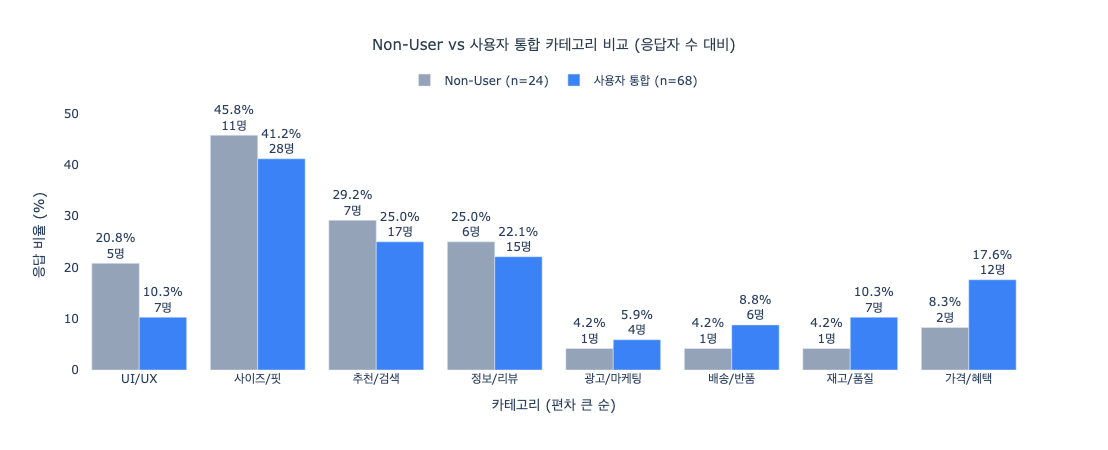

In [29]:
# Non-User vs 사용자 통합 비교 시각화
cats_sorted = compare.index.tolist()

fig = go.Figure()
fig.add_trace(go.Bar(
    name=f'Non-User (n={non_n})',
    x=cats_sorted,
    y=compare['Non-User 비율(%)'],
    text=[f'{p}%<br>{int(n)}명' for p, n in zip(compare['Non-User 비율(%)'], compare['Non-User 응답수'])],
    textposition='outside',
    marker_color=GROUP_COLOR['Non-User'],
))
fig.add_trace(go.Bar(
    name=f'사용자 통합 (n={user_n})',
    x=cats_sorted,
    y=compare['사용자 통합 비율(%)'],
    text=[f'{p}%<br>{int(n)}명' for p, n in zip(compare['사용자 통합 비율(%)'], compare['사용자 통합 응답수'])],
    textposition='outside',
    marker_color='#3B82F6',
))

fig.update_layout(
    title=dict(text='Non-User vs 사용자 통합 카테고리 비교 (응답자 수 대비)',
               x=0.5, xanchor='center', font=dict(size=15, color='#2c3e50')),
    xaxis_title='카테고리 (편차 큰 순)',
    yaxis_title='응답 비율 (%)',
    barmode='group',
    plot_bgcolor='white',
    yaxis=dict(range=[0, max(compare['Non-User 비율(%)'].max(), compare['사용자 통합 비율(%)'].max()) * 1.15]),
    height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig.show()

In [30]:
# Non-User 인구통계 프로파일 (성별·연령·콘텐츠 탐색 빈도·월 지출)
non_demo = run('nonuser_demo')  # SQL에서 비해당 제외 → 24명

print(f'Non-User 응답자 {len(non_demo)}명 인구통계\n')
for col, label in [('gender', '성별'), ('age', '연령대'),
                   ('content_freq', '콘텐츠 탐색 빈도'), ('monthly_spend', '월 지출')]:
    vc = non_demo[col].value_counts()
    pct = (vc / len(non_demo) * 100).round(1)
    print(f'=== {label} ===')
    for k, v in vc.items():
        print(f'  {k}: {v}명 ({pct[k]}%)')
    print()


Non-User 응답자 24명 인구통계

=== 성별 ===
  남성: 19명 (79.2%)
  여성: 5명 (20.8%)

=== 연령대 ===
  20대 후반: 10명 (41.7%)
  30대: 7명 (29.2%)
  20대 초중반: 6명 (25.0%)
  40대 이상: 1명 (4.2%)

=== 콘텐츠 탐색 빈도 ===
  가끔 본다: 14명 (58.3%)
  보통이다: 6명 (25.0%)
  전혀 찾아보지 않는다: 4명 (16.7%)

=== 월 지출 ===
  5만원 미만: 16명 (66.7%)
  5~10만원: 5명 (20.8%)
  30만원 이상: 1명 (4.2%)
  20~30만원: 1명 (4.2%)
  10~20만원: 1명 (4.2%)



In [31]:
# 행동 상태를 과잉 추론하지 않도록 명시적 표현만 시그널로 분류
SIGNAL_PATTERNS = {
    '명시적 이탈': [
        r'(사용|이용|쓰).{0,12}(하다가|했지만|했는데).{0,12}(중단|그만|지웠|삭제|탈퇴|해지)',
        r'(앱|어플).{0,20}(지웠|삭제|탈퇴|해지)',
        r'더\s*이상.{0,8}(사용|이용).{0,4}(않|안)',
    ],
    '초보·진입 어려움': [
        r'초보', r'처음\s*(사용|이용)', r'(사용|이용).{0,5}(해\s*본\s*적|경험).{0,5}(없)',
        r'안\s*해봤',
    ],
    '비대면 구매 장벽': [
        r'직접.{0,8}(입어|착용|확인)', r'(입어|착용).{0,8}(볼\s*수\s*없|못)',
        r'실물.{0,8}(확인|차이|다르)', r'실제.{0,8}(핏|착용|사이즈)',
        r'사이즈.{0,8}(미스|실패)',
    ],
}

def has_signal(text, patterns):
    if pd.isna(text):
        return False
    return any(re.search(pattern, str(text), flags=re.IGNORECASE) for pattern in patterns)

# 사용자와 Non-User에 동일 규칙을 적용해 비교 가능하게 구성
signal_flags = df[['user_id', 'user_group', 'feedback']].copy()
for sig_type, patterns in SIGNAL_PATTERNS.items():
    signal_flags[sig_type] = signal_flags['feedback'].apply(lambda x: has_signal(x, patterns))

signal_by_group = signal_flags.groupby('user_group')[list(SIGNAL_PATTERNS)].agg(['sum', 'mean'])
for sig_type in SIGNAL_PATTERNS:
    signal_by_group[(sig_type, 'mean')] = (signal_by_group[(sig_type, 'mean')] * 100).round(1)
display(signal_by_group)

non_demo = non_demo.merge(
    signal_flags[['user_id'] + list(SIGNAL_PATTERNS)],
    on='user_id',
    how='left',
    validate='one_to_one',
)
non_demo['signals'] = non_demo.apply(
    lambda row: [sig for sig in SIGNAL_PATTERNS if row[sig]], axis=1
)

print(f'Non-User {len(non_demo)}명 중 보수적 시그널 매칭')
for sig_type in SIGNAL_PATTERNS:
    cnt = int(non_demo[sig_type].sum())
    print(f'  {sig_type}: {cnt}명 ({cnt/len(non_demo)*100:.1f}%)')
print(f'  시그널 없음: {non_demo["signals"].apply(len).eq(0).sum()}명')

print('\n=== 시그널 매칭 응답 전수 감사 ===')
for sig_type in SIGNAL_PATTERNS:
    print(f'\n[{sig_type}]')
    matched = non_demo[non_demo[sig_type]]
    for _, r in matched.iterrows():
        print(f'  • [{r.gender}/{r.age}] "{r.feedback}"')

명시적 이탈      초보·진입 어려움      비대면 구매 장벽      
              sum mean       sum mean       sum  mean
user_group                                           
Detractor       0  0.0         0  0.0         1   3.2
Non-User        1  4.2         2  8.3         5  20.8
Passive         0  0.0         0  0.0         0   0.0
Promoter        0  0.0         0  0.0         0   0.0

Non-User 24명 중 보수적 시그널 매칭
  명시적 이탈: 1명 (4.2%)
  초보·진입 어려움: 2명 (8.3%)
  비대면 구매 장벽: 5명 (20.8%)
  시그널 없음: 17명

=== 시그널 매칭 응답 전수 감사 ===

[명시적 이탈]
  • [남성/20대 후반] "현재는 앱 사용은 안해서 지웠지만, 앱마다 사이즈 표기가 조금씩 달라서 실패할 때가 많아요. 체형별로 실제 착용 리뷰를 더 필터링해서 볼 수 있는 기능이 정교해지면 좋겠습니다."

[초보·진입 어려움]
  • [남성/20대 후반] "초보자의 입장에서는 보기 조금 어려운거같음"
  • [남성/20대 후반] "처음 사용하는 사람들에게 직관적으로 보이지 않았음(무신사)
항상 필요한 치수는 없음(크림)"

[비대면 구매 장벽]
  • [남성/20대 초중반] "실제 핏 확인 불가"
  • [여성/30대] "실제로 입는거랑 옷핏이 다른 점이 큼"
  • [남성/30대] "입어볼 수없어서 사이즈 미스"
  • [여성/40대 이상] "실제 입어볼 수 없어서. 실제 사이즈 핏을 예상할 수 없어서. 배송의 불편함 등"
  • [남성/20대 후반] "현재는 앱 사용은 안해서 지웠지만, 앱마다 사이즈 표기가 조금씩 달라서 실패할 때가 많아요. 체형별로 실제 착용 리뷰를 더 필터링해서 볼 수 있는 기능이 정교해지면 좋겠습니다."


### 분석 질문 2 결과: 차별은 비대면 장벽에 한정, 운영 불만↓은 구조적
_인구통계 SQL: `nonuser_demo` · 시그널 패턴: pandas_


Non-User 24명 중 비대면 구매 장벽 5명(20.8%), 초보·진입 어려움 2명(8.3%), 명시적 이탈 1명(4.2%)으로, 사용자에겐 거의 없는 비대면 장벽이 가장 뚜렷한 차이다. 운영 영역(가격/혜택 -9.3%p, 재고/품질 -6.1%p)이 낮은 것은 앱 미사용으로 노출 자체가 적은 구조적 결과로 본다. UI/UX +10.5%p는 5명 기반이라 분류 변동에 민감해 단독 근거로 보기는 어렵다.

> ### 섹션 결론
> - Non-User만의 차별은 **비대면 구매 장벽 시그널 20.8%(5명)** 에 한정되고, 사이즈/핏·정보/리뷰 등은 사용자와 비슷하다.
> - 운영 영역(가격·재고·배송) 불만이 낮은 것은 앱 미사용에 따른 구조적 결과이며, 명시적 이탈 1명·미진입 2명은 Q5 단일응답으로는 안 보이던 정보다.
> - 인구통계(남성 79.2%·월 지출 5만원 미만 66.7% 등)는 응답자 24명의 프로파일일 뿐 전체 Non-User로 일반화하지 않는다.

---

## 결론 및 핵심 인사이트

Q18 유효응답 92건 정성 분석 결과, 사이즈/핏(42.4%)이 최대 불만 영역이고 추천/검색·정보/리뷰가 뒤를 잇는다. Detractor 특유의 집중 패턴은 약해 `03_nps` 발견 4와 같은 방향이며, Non-User의 차별은 비대면 구매 장벽 시그널에 한정된다. UI/UX는 자동 분류에서 과대 집계될 수 있어 원문 감사 기준 12건으로 확정했다. 모든 비율은 다중응답·소표본 기반이라 탐색적 신호로 읽는다.

---

### 통계/기술 분석 요약

자유응답 다중카테고리 특성상 카이제곱·잔차 검정은 적용하지 않고 기술통계 + 원문 전수 감사 중심으로 진행했다.

| 섹션 | 분석 방법 | 결과 |
|---|---|---|
| 1 — 응답 분포 | 응답자 수·비율 | 응답률 29.2-36.4%, 그룹 차이 작음 |
| 2 — 키워드 빈도 | Okt 명사 빈도 | 사이즈 26·옷 20·리뷰 17 상위 |
| 3 — 카테고리 분류 | 다중 라벨 전수 감사 | 사이즈/핏 42.4%·추천/검색 26.1%·정보/리뷰 22.8% |
| 4 — Detractor × 카테고리 | 그룹 vs 나머지 편차(%p) | 특수 집중 약함, 가격 +11.1%p·추천 +9.3%p |
| 5 — Non-User vs 사용자 | 편차 + 시그널 추출 | 비대면 장벽 20.8%, 운영 불만 낮음은 구조적 |

---

### 핵심 발견 요약

- **발견 1: 사이즈/핏(42.4%)이 그룹 무관 최대 불만 영역** — 4그룹 모두 사이즈/핏이 상위 (섹션 1-3)
- **발견 2: Detractor 특수 집중은 약함** — 1위는 전체와 같고 가격·추천만 약한 탐색 신호 (섹션 4)
- **발견 3: Non-User 차별은 비대면 장벽에 한정** — 운영 불만↓은 구조적, 비대면 장벽 20.8%가 고유 신호 (섹션 5)

---

> 발견별 상세 근거·해석은 각 섹션의 `섹션 결론`을, 통계 방법론은 [docs/METHODS.md](../docs/METHODS.md)를 참조한다.


---

### SQL 기법 매핑

이 노트북에서 각 분석을 산출한 SQL 쿼리와 기법(검정·다중응답·NLP는 pandas).

| 섹션 | SQL 쿼리 | 기법 |
|------|---------|------|
| 추출·그룹 라벨 | `feedback_base`·`response_base`·`nonuser_demo` | CASE WHEN 라벨링 |
| 형태소·키워드·워드클라우드 | — | KoNLPy(Okt) → pandas |
| 카테고리 분류·NPS 교차 | — | 키워드 매칭 (DB 비파생) → pandas |
